In [ ]:
import pandas as pd
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer


In [ ]:

# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()



In [ ]:

# Load dataset
path = "/content/Resume-final-v3.csv"

In [ ]:

df = pd.read_csv(path).dropna()  # Remove empty rows


In [ ]:
######################################################
if 'index' not in df.columns:
    df.insert(0, 'index', range(1, len(df) + 1))
else:
    print("Column 'index' already exists in the DataFrame.")
##############################################################


In [ ]:
# Convert text to lowercase
df['Resume'] = df['Resume'].str.lower()



In [ ]:


# Remove duplicates
df.drop_duplicates(inplace=True)


In [ ]:

# Define stop words
stop_words = set(stopwords.words('english'))


In [ ]:

# Text preprocessing function (before tokenization)
def preprocess_text(text):
    if isinstance(text, str):
        text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters, keep letters and spaces
        text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
        text = re.sub('http\S+\s*', ' ', text)  # remove URLs
        text = re.sub('RT|cc', ' ', text)  # remove RT and cc
        text = re.sub('#\S+', '', text)  # remove hashtags
        text = re.sub('@\S+', '  ', text)  # remove mentions
        text = re.sub('[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""), ' ', text)
# remove punctuations
        text = re.sub(r'[^\x00-\x7f]',r' ', text)
        text = re.sub('\s+', ' ', text)  # remove extra whitespace

        return text
    return ""


In [ ]:

# Apply preprocessing to the 'Resume' column
df['Cleaned_Resume'] = df['Resume'].apply(preprocess_text)


In [ ]:

# Tokenize AFTER cleaning
df['tokens'] = df['Cleaned_Resume'].apply(word_tokenize)


In [ ]:

# Remove stopwords, apply stemming and lemmatization to tokens
def process_tokens(tokens):
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    tokens = [stemmer.stem(word) for word in tokens]  # Apply stemming
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Apply lemmatization
    return tokens


In [ ]:

df['tokens'] = df['tokens'].apply(process_tokens)



In [ ]:
df.head()

,index,Category,Resume,Cleaned_Resume,tokens
0,1,Data Science,"areas of interest deep learning, control syste...",areas of interest deep learning control system...,"[area, interest, deep, learn, control, system,..."
1,2,Data Science,skills â¢ r â¢ python â¢ sap hana â¢ table...,skills r python sap hana tableau sap hana sql ...,"[skill, r, python, sap, hana, tableau, sap, ha..."
2,3,Data Science,"education details \n mca ymcaust, faridabad...",education details mca ymcaust faridabad haryan...,"[educ, detail, mca, ymcaust, faridabad, haryan..."
3,4,Data Science,"skills c basics, iot, python, matlab, data sci...",skills c basics iot python matlab data science...,"[skill, c, basic, iot, python, matlab, data, s..."
4,5,Data Science,skills â¢ python â¢ tableau â¢ data visuali...,skills python tableau data visualization r stu...,"[skill, python, tableau, data, visual, r, stud..."


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import joblib


In [ ]:

df.head()


,index,Category,Resume,Cleaned_Resume,tokens
0,1,Data Science,"areas of interest deep learning, control syste...",areas of interest deep learning control system...,"[area, interest, deep, learn, control, system,..."
1,2,Data Science,skills â¢ r â¢ python â¢ sap hana â¢ table...,skills r python sap hana tableau sap hana sql ...,"[skill, r, python, sap, hana, tableau, sap, ha..."
2,3,Data Science,"education details \n mca ymcaust, faridabad...",education details mca ymcaust faridabad haryan...,"[educ, detail, mca, ymcaust, faridabad, haryan..."
3,4,Data Science,"skills c basics, iot, python, matlab, data sci...",skills c basics iot python matlab data science...,"[skill, c, basic, iot, python, matlab, data, s..."
4,5,Data Science,skills â¢ python â¢ tableau â¢ data visuali...,skills python tableau data visualization r stu...,"[skill, python, tableau, data, visual, r, stud..."


In [ ]:

# Replace NaN values with empty strings in the 'Resume' column
df['tokens'] = df['tokens'].fillna('')

In [ ]:

 #Drop rows with NaN in 'Category' column
df.dropna(subset=['Category'], inplace=True)


In [ ]:

# Assumes `Resume` column contains resume text and `Category` column contains target labels
resumes = df['tokens']
categories = df['Category']


In [ ]:

category_counts = df['Category'].value_counts()
filtered_category_counts = category_counts[category_counts >= 2]
print(filtered_category_counts)


Category
HR                           259
INFORMATION-TECHNOLOGY       238
BUSINESS-DEVELOPMENT         236
FITNESS                      233
SALES                        230
CONSULTANT                   230
HEALTHCARE                   226
DESIGNER                     212
TEACHER                      204
DIGITAL-MEDIA                190
ADVOCATE                     183
CHEF                         128
AGRICULTURE                  126
AVIATION                     117
ACCOUNTANT                   116
ENGINEERING                  116
FINANCE                      116
BANKING                      115
CONSTRUCTION                 111
PUBLIC-RELATIONS             110
ARTS                         103
APPAREL                       96
Java Developer                84
Testing                       70
AUTOMOBILE                    68
DevOps Engineer               55
Python Developer              48
Web Designing                 43
BPO                           42
Hadoop                        42
M

In [ ]:

filtered_categories = filtered_category_counts.index
print(filtered_categories)


Index(['HR', 'INFORMATION-TECHNOLOGY', 'BUSINESS-DEVELOPMENT', 'FITNESS',
       'SALES', 'CONSULTANT', 'HEALTHCARE', 'DESIGNER', 'TEACHER',
       'DIGITAL-MEDIA', 'ADVOCATE', 'CHEF', 'AGRICULTURE', 'AVIATION',
       'ACCOUNTANT', 'ENGINEERING', 'FINANCE', 'BANKING', 'CONSTRUCTION',
       'PUBLIC-RELATIONS', 'ARTS', 'APPAREL', 'Java Developer', 'Testing',
       'AUTOMOBILE', 'DevOps Engineer', 'Python Developer', 'Web Designing',
       'BPO', 'Hadoop', 'Mechanical Engineer', 'Operations Manager',
       'Blockchain', 'ETL Developer', 'Sales', 'Database',
       'Electrical Engineering', 'Health and fitness', 'PMO',
       'DotNet Developer', 'Business Analyst', 'Data Science', 'Arts',
       'Automation Testing', 'Network Security Engineer', 'SAP Developer',
       'Civil Engineer', 'Advocate'],
      dtype='object', name='Category')


In [ ]:

# Step 6: Encode Target Labels
le = LabelEncoder()

In [ ]:

# Filter the DataFrame to include only the filtered categories
df_filtered = df[df['Category'].isin(filtered_categories)]


In [ ]:

# Now, fit_transform on the 'Category' column of the filtered DataFrame
df_filtered['Category_encoded'] = le.fit_transform(df_filtered['Category'])
y = df_filtered['Category_encoded']  # Encoded labels


<ipython-input-55-9bb5b6305009>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Category_encoded'] = le.fit_transform(df_filtered['Category'])


In [ ]:

# Save the LabelEncoder
joblib.dump(le, 'xgboost_LabelEncoder.pkl')


['xgboost_LabelEncoder.pkl']

In [ ]:

# Step 2: Feature Extraction using TF-IDF
tfidf = TfidfVectorizer(sublinear_tf=True,
    stop_words='english',
    max_features=1500)  # You can adjust max_features


In [ ]:


# Filter the resumes based on the filtered categories
filtered_resumes = df[df['Category'].isin(filtered_categories)]['tokens']


In [ ]:

# Join the tokens back into strings before passing to TF-IDF
filtered_resumes = filtered_resumes.apply(lambda tokens: ' '.join(tokens))


In [ ]:

X = tfidf.fit_transform(filtered_resumes).toarray()


In [ ]:

# Save the Vectorizer
joblib.dump(tfidf, 'xgboost_Model_Vectorizer.pkl')


['xgboost_Model_Vectorizer.pkl']

In [ ]:

# Step 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:

# Model Training and Testing
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:

# Predict on the training data:
y_train_pred = xgb_model.predict(X_train)


In [ ]:
# Calculate training accuracy:
train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy Score:", train_accuracy)


Training Accuracy Score: 1.0


In [ ]:

#Save the Trained Model
joblib.dump(xgb_model, 'xgboost_Model.pkl')


['xgboost_Model.pkl']

In [ ]:

# Calculate and print the accuracy score
xgb_prediction = xgb_model.predict(X_test)  # Predict on the test data
accuracy = accuracy_score(y_test, xgb_prediction)
print("Testing Accuracy Score:", accuracy)


Testing Accuracy Score: 0.8799715909090909


In [ ]:

# Predict on the testing data to get the predicted labels
y_pred = xgb_model.predict(X_train)


In [ ]:

# Use the actual true labels from the testing set (y_test)
y_true = y_train


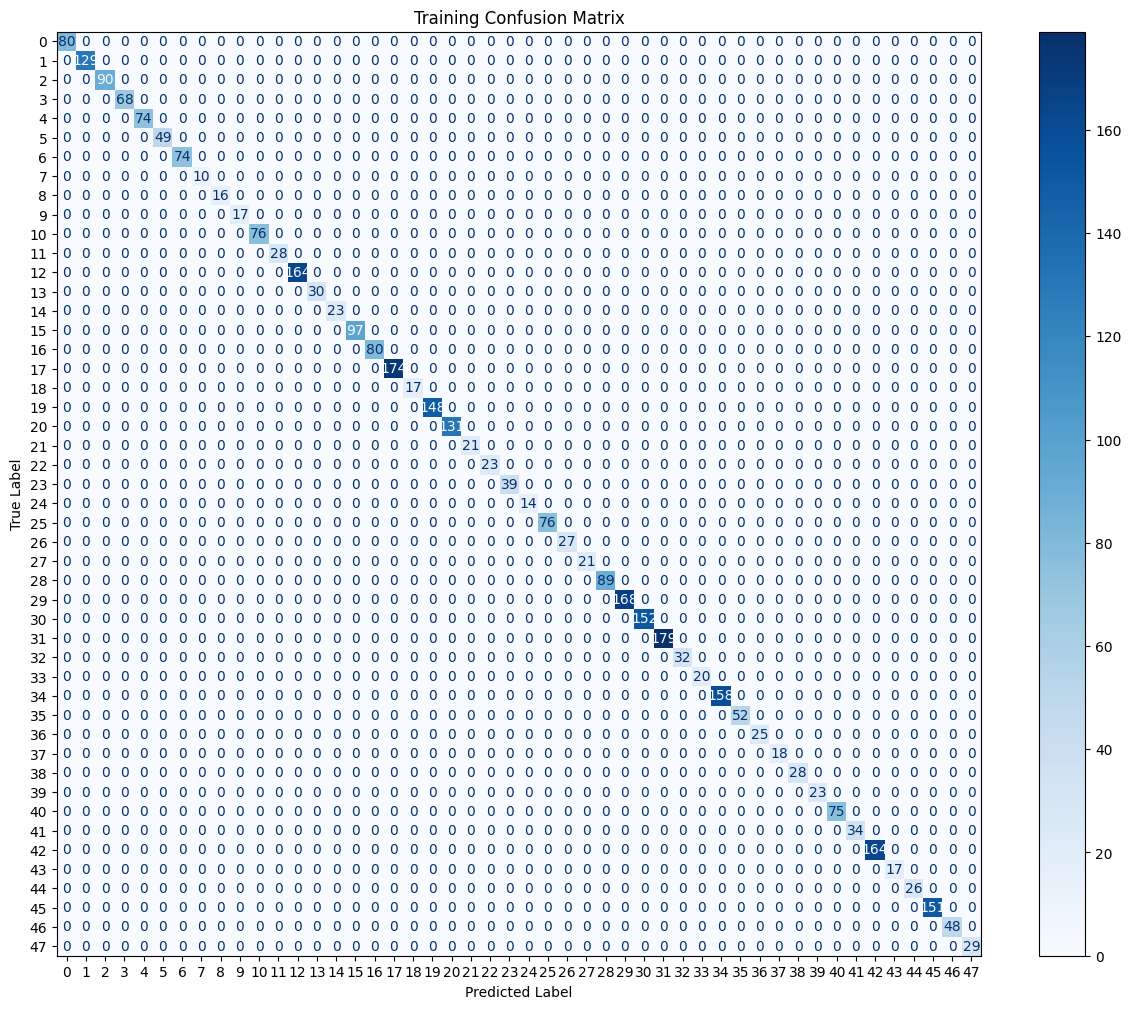

In [ ]:

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)
# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(15,12))
disp.plot(ax=ax, cmap=plt.cm.Blues)


# Add labels and title
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.title("Training Confusion Matrix")

# Show the plot
plt.show()


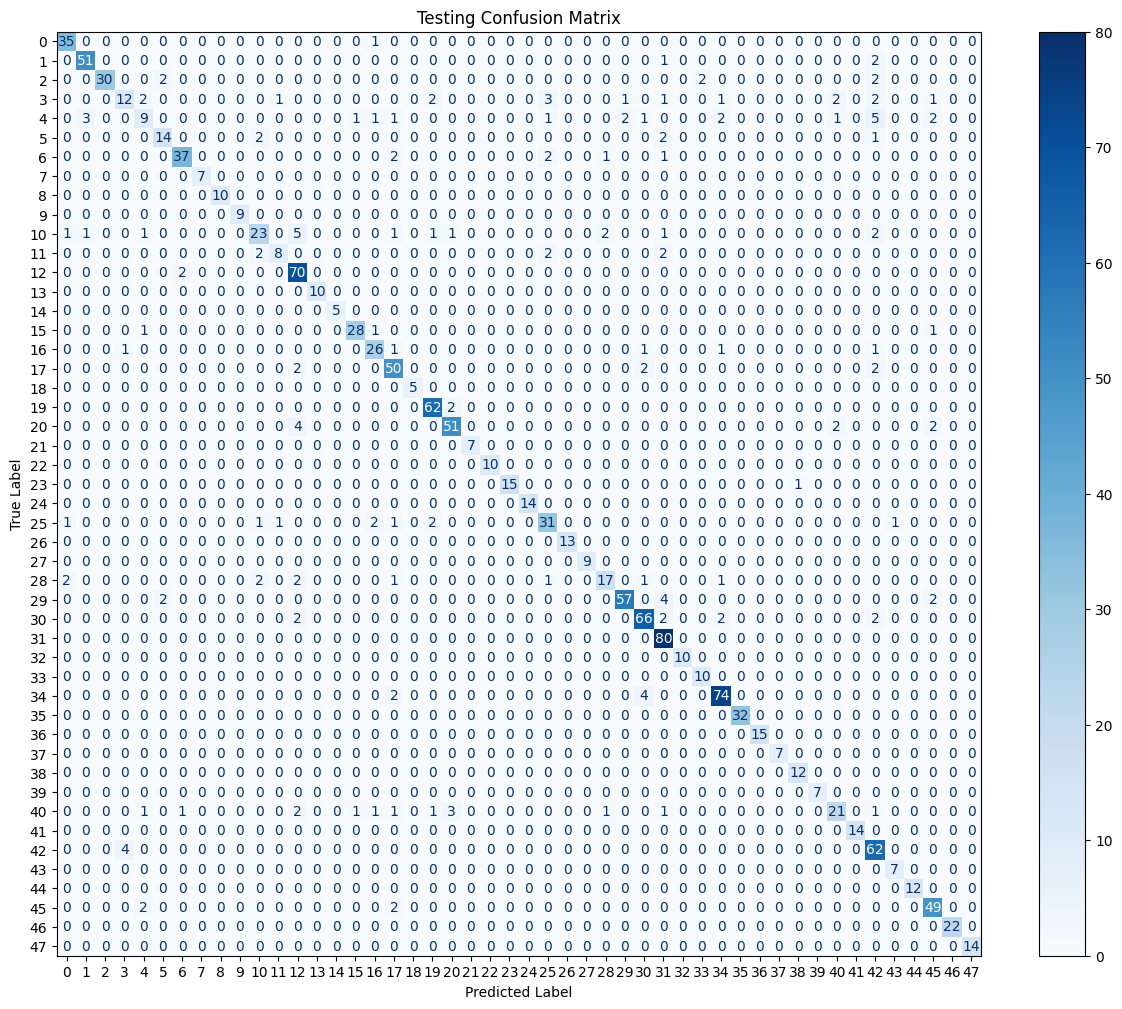

In [ ]:


# Predict on the testing data to get the predicted labels
y_pred = xgb_model.predict(X_test)

# Use the actual true labels from the testing set (y_test)
y_true = y_test

# Generate the confusion matrix
cm = confusion_matrix(y_true, y_pred)
# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(15,12))
disp.plot(ax=ax, cmap=plt.cm.Blues)


# Add labels and title
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.title("Testing Confusion Matrix")

# Show the plot
plt.show()


In [ ]:

# Step 9: Ranking Resumes within a Category
def rank_resumes(category, resumes, classifier, tfidf, label_encoder):
    # Get the label for the specified category
    category_label = label_encoder.transform([category])[0]
    # Filter resumes belonging to a category
    category_resumes = df[df['Category'] == category]['tokens']
    # Join the tokens back into strings before transforming
    category_resumes = category_resumes.apply(lambda tokens: ' '.join(tokens))
    category_features = tfidf.transform(category_resumes)

    # Generate scores based on probabilities for the given category
    scores = classifier.predict_proba(category_features)[:, category_label]

    # Rank resumes by scores
    ranked_indices = np.argsort(scores)[::-1]
    ranked_resumes = category_resumes.iloc[ranked_indices]
    return ranked_resumes


In [ ]:
# Example: Rank Resumes for a Specific Category
cat=input("Enter the category to rank (CAPITAL LETTERS): ")
category_to_rank = cat  # Replace with your desired category
ranked_resumes = rank_resumes(category_to_rank, df['tokens'], xgb_model, tfidf, le)


Enter the category to rank (CAPITAL LETTERS): HR


In [ ]:

# Display Top Ranked Resumes
quant=input("Enter the number of resumes to display (NUMERIC): ")
quant=int(quant)
print(f"Top-ranked resumes for category '{category_to_rank}':")
print(ranked_resumes[:quant])  # Display top 5 resumes

Enter the number of resumes to display (NUMERIC): 5
Top-ranked resumes for category 'HR':
1036    hr specialist horizont engin profession summar...
2350    hr specialist horizont engin profession summar...
2250    hr manag summari human resourc manag practic u...
939     hr manag summari human resourc manag practic u...
988     hr coordin summari obtain human resourc genera...
Name: tokens, dtype: object
